<a href="https://colab.research.google.com/github/igordepaulasousa/igordepaulasousa/blob/main/mulheres_eleitas_prefeitas_no_ES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Quantas mulheres foram eleitas para as prefeituras capixabas de 2004 a 2024?

In [210]:
#importando o pandas e o matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Descobrindo a quantidade de mulheres eleitas prefeitas em 2004

In [148]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [149]:
#importando a tabela de votação de 2004
colunas = ['NM_MUNICIPIO', 'DS_CARGO','NM_VOTAVEL','QT_VOTOS','ANO_ELEICAO']
df = pd.read_csv('/content/votacao_secao_2004_ES.csv', delimiter= ';', encoding='latin-1', usecols= colunas)
df.head()

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO,NM_VOTAVEL,QT_VOTOS
0,2004,AFONSO CLAUDIO,Prefeito,EDELIO FRANCISCO GUEDES,198
1,2004,AFONSO CLAUDIO,Prefeito,LUIZ TEMOTEO DIAS VIEIRA,93
2,2004,AFONSO CLAUDIO,Prefeito,VICENTE DE PAULO LEITE,14
3,2004,AFONSO CLAUDIO,Prefeito,VOTO BRANCO,8
4,2004,AFONSO CLAUDIO,Prefeito,VOTO NULO,15


In [151]:
#Descobrindo os prefeitos eleitos
mais_votados = df.loc[df.groupby(['NM_MUNICIPIO','DS_CARGO'])['QT_VOTOS'].idxmax()]
mais_votados['DS_CARGO'] = mais_votados['DS_CARGO'].str.upper()
mais_votados = mais_votados[mais_votados['DS_CARGO'] == 'PREFEITO']
mais_votados

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO,NM_VOTAVEL,QT_VOTOS
3849,2004,AFONSO CLAUDIO,PREFEITO,EDELIO FRANCISCO GUEDES,255
4815,2004,AGUA DOCE DO NORTE,PREFEITO,ABRAÃO LINCON ELIZEU ...,177
5997,2004,AGUIA BRANCA,PREFEITO,JAILSON JOSÉ QUIUQUI,212
10076,2004,ALEGRE,PREFEITO,DJALMA DA SILVA SANTOS,301
10867,2004,ALFREDO CHAVES,PREFEITO,FERNANDO VIDEIRA LAFAYETTE,234
11743,2004,ALTO RIO NOVO,PREFEITO,ALDO SOARES DE OLIVEIRA,183
13649,2004,ANCHIETA,PREFEITO,EDIVAL JOSÉ PETRI,229
15304,2004,APIACA,PREFEITO,JOSÉ CHIERICI FILHO,163
22018,2004,ARACRUZ,PREFEITO,ADEMAR COUTINHO DEVENS,233
27693,2004,ATILIO VIVACQUA,PREFEITO,HELIO HUMBERTO LIMA,223


In [152]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [153]:
#importando a tabela de candidaturas para utilizar a coluna de gênero
colunas = ['NM_UE', 'DS_CARGO', 'NM_CANDIDATO', 'DS_GENERO', 'DS_GRAU_INSTRUCAO']
candidatos = pd.read_csv('/content/consulta_cand_2004_ES.csv', delimiter= ';', encoding= 'latin-1', usecols= colunas)
candidatos.head()

,NM_UE,DS_CARGO,NM_CANDIDATO,DS_GENERO,DS_GRAU_INSTRUCAO
0,ECOPORANGA,VEREADOR,ANA CRISTINA SERPA PORTUGAL,FEMININO,NÃO INFORMADO
1,ALEGRE,VEREADOR,ALCEBIADES BAPTISTA SOBREIRA,MASCULINO,NÃO INFORMADO
2,SERRA,PREFEITO,JOÃO GILBERTI SARTÓRIO,MASCULINO,SUPERIOR INCOMPLETO
3,MUQUI,VEREADOR,ADDA MARIA MONTEIRO LOBATO MACHADO,FEMININO,SUPERIOR COMPLETO
4,ANCHIETA,VEREADOR,LUIZ CELSO DE AZEVEDO,MASCULINO,MÉDIO INCOMPLETO


In [154]:
#juntando as tabelas de eleitos e candidatos
nova_tabela = pd.merge(mais_votados, candidatos, left_on= 'NM_VOTAVEL', right_on= 'NM_CANDIDATO', how= 'inner')
nova_tabela

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO_x,NM_VOTAVEL,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO,DS_GRAU_INSTRUCAO
0,2004,AFONSO CLAUDIO,PREFEITO,EDELIO FRANCISCO GUEDES,255,AFONSO CLAUDIO,PREFEITO,EDELIO FRANCISCO GUEDES,MASCULINO,FUNDAMENTAL INCOMPLETO
1,2004,AGUIA BRANCA,PREFEITO,JAILSON JOSÉ QUIUQUI,212,AGUIA BRANCA,PREFEITO,JAILSON JOSÉ QUIUQUI,MASCULINO,SUPERIOR COMPLETO
2,2004,ALEGRE,PREFEITO,DJALMA DA SILVA SANTOS,301,ALEGRE,PREFEITO,DJALMA DA SILVA SANTOS,MASCULINO,SUPERIOR COMPLETO
3,2004,ALFREDO CHAVES,PREFEITO,FERNANDO VIDEIRA LAFAYETTE,234,ALFREDO CHAVES,PREFEITO,FERNANDO VIDEIRA LAFAYETTE,MASCULINO,SUPERIOR COMPLETO
4,2004,ALTO RIO NOVO,PREFEITO,ALDO SOARES DE OLIVEIRA,183,ALTO RIO NOVO,PREFEITO,ALDO SOARES DE OLIVEIRA,MASCULINO,FUNDAMENTAL INCOMPLETO
5,2004,ANCHIETA,PREFEITO,EDIVAL JOSÉ PETRI,229,ANCHIETA,PREFEITO,EDIVAL JOSÉ PETRI,MASCULINO,SUPERIOR COMPLETO
6,2004,APIACA,PREFEITO,JOSÉ CHIERICI FILHO,163,APIACA,PREFEITO,JOSÉ CHIERICI FILHO,MASCULINO,SUPERIOR COMPLETO
7,2004,ARACRUZ,PREFEITO,ADEMAR COUTINHO DEVENS,233,ARACRUZ,PREFEITO,ADEMAR COUTINHO DEVENS,MASCULINO,SUPERIOR COMPLETO
8,2004,ATILIO VIVACQUA,PREFEITO,HELIO HUMBERTO LIMA,223,ATILIO VIVACQUA,PREFEITO,HELIO HUMBERTO LIMA,MASCULINO,SUPERIOR COMPLETO
9,2004,BAIXO GUANDU,PREFEITO,LASTÊNIO LUIZ CARDOSO,280,BAIXO GUANDU,PREFEITO,LASTÊNIO LUIZ CARDOSO,MASCULINO,SUPERIOR COMPLETO


In [155]:
#filtrando apenas as mulheres eleitas
mulheres_2004 = nova_tabela[nova_tabela['DS_GENERO'] == 'FEMININO']
mulheres_2004

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO_x,NM_VOTAVEL,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO,DS_GRAU_INSTRUCAO
25,2004,FUNDAO,PREFEITO,MARIA DULCE RUDIO SOARES,199,FUNDAO,PREFEITO,MARIA DULCE RUDIO SOARES,FEMININO,SUPERIOR COMPLETO
35,2004,ITAPEMIRIM,PREFEITO,NORMA AYUB ALVES,232,ITAPEMIRIM,PREFEITO,NORMA AYUB ALVES,FEMININO,SUPERIOR COMPLETO
64,2004,SAO DOMINGOS,PREFEITO,ANA IZABEL MALACARNE DE OLIVEIRA,101,SAO DOMINGOS,PREFEITO,ANA IZABEL MALACARNE DE OLIVEIRA,FEMININO,SUPERIOR COMPLETO
65,2004,SAO GABRIEL DA PALHA,PREFEITO,RAQUEL FERREIRA MAGESTE LESSA,205,SAO GABRIEL DA PALHA,PREFEITO,RAQUEL FERREIRA MAGESTE LESSA,FEMININO,SUPERIOR COMPLETO
73,2004,VIANA,PREFEITO,SOLANGE SIQUEIRA LUBE,202,VIANA,PREFEITO,SOLANGE SIQUEIRA LUBE,FEMININO,SUPERIOR INCOMPLETO


Descobrindo a quantidade de mulheres eleitas prefeitas em 2008

In [156]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [157]:
colunas = ['NM_MUNICIPIO', 'DS_CARGO','NM_VOTAVEL','QT_VOTOS','ANO_ELEICAO']
resultado_2008 = pd.read_csv('/content/votacao_secao_2008_ES.csv', delimiter=';', encoding= 'latin-1', usecols= colunas)
resultado_2008.head()

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO,NM_VOTAVEL,QT_VOTOS
0,2008,AFONSO CLÁUDIO,Prefeito,ALTAMIRO THADEU FRONTINO SOBREIRO,61
1,2008,AFONSO CLÁUDIO,Prefeito,LUIZ TEMOTEO DIAS VIEIRA,68
2,2008,AFONSO CLÁUDIO,Prefeito,OSMAR XAVIER,8
3,2008,AFONSO CLÁUDIO,Prefeito,VOTO BRANCO,6
4,2008,AFONSO CLÁUDIO,Prefeito,VOTO NULO,14


In [158]:
mais_votados_2008 = resultado_2008.loc[resultado_2008.groupby(['NM_MUNICIPIO','DS_CARGO'])['QT_VOTOS'].idxmax()]
mais_votados_2008['DS_CARGO'] = mais_votados_2008['DS_CARGO'].str.upper()
mais_votados_2008 = mais_votados_2008[mais_votados_2008['DS_CARGO'] == 'PREFEITO']
mais_votados_2008

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO,NM_VOTAVEL,QT_VOTOS
1993,2008,AFONSO CLÁUDIO,PREFEITO,WILSON BERGER COSTA,171
7424,2008,ALEGRE,PREFEITO,DJALMA DA SILVA SANTOS,273
8800,2008,ALFREDO CHAVES,PREFEITO,FERNANDO VIDEIRA LAFAYETTE,228
9541,2008,ALTO RIO NOVO,PREFEITO,EDSON SOARES BENFICA,248
11029,2008,ANCHIETA,PREFEITO,EDIVAL JOSÉ PETRI,311
13667,2008,APIACÁ,PREFEITO,HUMBERTO ALVES DE SOUZA,191
19646,2008,ARACRUZ,PREFEITO,ADEMAR COUTINHO DEVENS,289
23813,2008,ATÍLIO VIVÁCQUA,PREFEITO,JOSE LUIZ TORRES LOPES,230
25858,2008,BAIXO GUANDU,PREFEITO,LASTENIO LUIZ CARDOSO,204
29746,2008,BARRA DE SÃO FRANCISCO,PREFEITO,WALDELES CAVALCANTE,210


In [159]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [160]:
colunas = ['NM_UE', 'DS_CARGO', 'NM_CANDIDATO', 'DS_GENERO', 'DS_GRAU_INSTRUCAO']
candidatos_2008 = pd.read_csv('/content/consulta_cand_2008_ES.csv', delimiter= ';', encoding= 'latin-1', usecols= colunas)
candidatos_2008.head()

,NM_UE,DS_CARGO,NM_CANDIDATO,DS_GENERO,DS_GRAU_INSTRUCAO
0,FUNDÃO,VEREADOR,JOSE LORICO SIQUEIRA,MASCULINO,ENSINO MÉDIO COMPLETO
1,VILA PAVÃO,VEREADOR,AILSON LENKE ALVES,MASCULINO,ENSINO FUNDAMENTAL COMPLETO
2,COLATINA,VEREADOR,ANTONIO CARLOS PAULO,MASCULINO,ENSINO FUNDAMENTAL INCOMPLETO
3,VILA VELHA,VEREADOR,AURELIO ROBSON FONSECA DA SILVA,MASCULINO,ENSINO MÉDIO COMPLETO
4,SOORETAMA,VEREADOR,ERALDO DE OLIVEIRA GOMES,MASCULINO,ENSINO FUNDAMENTAL COMPLETO


In [161]:
tabela2 = pd.merge(mais_votados_2008, candidatos_2008, left_on='NM_VOTAVEL', right_on='NM_CANDIDATO', how='inner')
tabela2

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO_x,NM_VOTAVEL,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO,DS_GRAU_INSTRUCAO
0,2008,AFONSO CLÁUDIO,PREFEITO,WILSON BERGER COSTA,171,AFONSO CLÁUDIO,PREFEITO,WILSON BERGER COSTA,MASCULINO,SUPERIOR COMPLETO
1,2008,ALEGRE,PREFEITO,DJALMA DA SILVA SANTOS,273,ALEGRE,PREFEITO,DJALMA DA SILVA SANTOS,MASCULINO,SUPERIOR COMPLETO
2,2008,ALFREDO CHAVES,PREFEITO,FERNANDO VIDEIRA LAFAYETTE,228,ALFREDO CHAVES,PREFEITO,FERNANDO VIDEIRA LAFAYETTE,MASCULINO,SUPERIOR COMPLETO
3,2008,ALTO RIO NOVO,PREFEITO,EDSON SOARES BENFICA,248,ALTO RIO NOVO,PREFEITO,EDSON SOARES BENFICA,MASCULINO,ENSINO FUNDAMENTAL INCOMPLETO
4,2008,ANCHIETA,PREFEITO,EDIVAL JOSÉ PETRI,311,ANCHIETA,PREFEITO,EDIVAL JOSÉ PETRI,MASCULINO,SUPERIOR COMPLETO
5,2008,APIACÁ,PREFEITO,HUMBERTO ALVES DE SOUZA,191,APIACÁ,PREFEITO,HUMBERTO ALVES DE SOUZA,MASCULINO,ENSINO MÉDIO COMPLETO
6,2008,APIACÁ,PREFEITO,HUMBERTO ALVES DE SOUZA,191,APIACÁ,PREFEITO,HUMBERTO ALVES DE SOUZA,MASCULINO,SUPERIOR INCOMPLETO
7,2008,ARACRUZ,PREFEITO,ADEMAR COUTINHO DEVENS,289,ARACRUZ,PREFEITO,ADEMAR COUTINHO DEVENS,MASCULINO,SUPERIOR COMPLETO
8,2008,ATÍLIO VIVÁCQUA,PREFEITO,JOSE LUIZ TORRES LOPES,230,ATÍLIO VIVÁCQUA,PREFEITO,JOSE LUIZ TORRES LOPES,MASCULINO,ENSINO FUNDAMENTAL INCOMPLETO
9,2008,BAIXO GUANDU,PREFEITO,LASTENIO LUIZ CARDOSO,204,BAIXO GUANDU,PREFEITO,LASTENIO LUIZ CARDOSO,MASCULINO,SUPERIOR COMPLETO


In [162]:
mulheres_2008 = tabela2[tabela2['DS_GENERO'] == 'FEMININO']
mulheres_2008

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO_x,NM_VOTAVEL,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO,DS_GRAU_INSTRUCAO
22,2008,DORES DO RIO PRETO,PREFEITO,CLAUDIA MARTINS BASTOS,210,DORES DO RIO PRETO,PREFEITO,CLAUDIA MARTINS BASTOS,FEMININO,SUPERIOR COMPLETO
29,2008,IBIRAÇU,PREFEITO,NACIENE LUZIA MODENESI VICENTE,186,IBIRAÇU,PREFEITO,NACIENE LUZIA MODENESI VICENTE,FEMININO,SUPERIOR COMPLETO
34,2008,ITAPEMIRIM,PREFEITO,NORMA AYUB ALVES,283,ITAPEMIRIM,PREFEITO,NORMA AYUB ALVES,FEMININO,SUPERIOR COMPLETO
44,2008,MARECHAL FLORIANO,PREFEITO,ELIANE PAES LORENZONI,190,MARECHAL FLORIANO,PREFEITO,ELIANE PAES LORENZONI,FEMININO,SUPERIOR COMPLETO
47,2008,MONTANHA,PREFEITO,IRACY CARVALHO MACHADO BALTAR FERNANDES,205,MONTANHA,PREFEITO,IRACY CARVALHO MACHADO BALTAR FERNANDES,FEMININO,SUPERIOR COMPLETO
64,2008,SOORETAMA,PREFEITO,JOANA DA CONCEIÇÃO RANGEL,208,SOORETAMA,PREFEITO,JOANA DA CONCEIÇÃO RANGEL,FEMININO,ENSINO MÉDIO INCOMPLETO
66,2008,SÃO GABRIEL DA PALHA,PREFEITO,RAQUEL FERREIRA MAGESTE LESSA,254,SÃO GABRIEL DA PALHA,PREFEITO,RAQUEL FERREIRA MAGESTE LESSA,FEMININO,SUPERIOR COMPLETO
72,2008,VIANA,PREFEITO,ANGELA MARIA SIAS,211,VIANA,PREFEITO,ANGELA MARIA SIAS,FEMININO,SUPERIOR COMPLETO


Descobrindo a quantidade de mulheres eleitas prefeitas em 2012

In [163]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [164]:
colunas = ['NM_MUNICIPIO', 'DS_CARGO','NM_VOTAVEL','QT_VOTOS','ANO_ELEICAO']
resultado_2012 = pd.read_csv('/content/votacao_secao_2012_ES.csv', delimiter= ';', encoding= 'latin-1', usecols = colunas)
resultado_2012.head()

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO,NM_VOTAVEL,QT_VOTOS
0,2012,AFONSO CLÁUDIO,Prefeito,EDELIO FRANCISCO GUEDES,85
1,2012,AFONSO CLÁUDIO,Prefeito,VOTO BRANCO,8
2,2012,AFONSO CLÁUDIO,Prefeito,VOTO NULO,15
3,2012,AFONSO CLÁUDIO,Prefeito,WILSON BERGER COSTA,181
4,2012,AFONSO CLÁUDIO,Vereador,ADEILDE DAVEL DE OLIVEIRA,8


In [165]:
mais_votados_2012 = resultado_2012.loc[resultado_2012.groupby(['NM_MUNICIPIO','DS_CARGO'])['QT_VOTOS'].idxmax()]
mais_votados_2012['DS_CARGO'] = mais_votados_2012['DS_CARGO'].str.upper()
mais_votados_2012 = mais_votados_2012[mais_votados_2012['DS_CARGO'] == 'PREFEITO']
mais_votados_2012

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO,NM_VOTAVEL,QT_VOTOS
2876,2012,AFONSO CLÁUDIO,PREFEITO,WILSON BERGER COSTA,257
5616,2012,ALEGRE,PREFEITO,PAULO LEMOS BARBOSA,202
8376,2012,ALFREDO CHAVES,PREFEITO,ROBERTO FORTUNATO FIORIN,234
9723,2012,ALTO RIO NOVO,PREFEITO,EDSON SOARES BENFICA,165
11265,2012,ANCHIETA,PREFEITO,RENATO LORENCINI,252
14067,2012,APIACÁ,PREFEITO,HUMBERTO ALVES DE SOUZA,205
15250,2012,ARACRUZ,PREFEITO,MARCELO DE SOUZA COELHO,259
29907,2012,ATÍLIO VIVÁCQUA,PREFEITO,JOSÉ LUIZ TORRES LOPES,190
31467,2012,BAIXO GUANDU,PREFEITO,JOSE DE BARROS NETO,197
39255,2012,BARRA DE SÃO FRANCISCO,PREFEITO,LUCIANO HENRIQUE SORDINE PEREIRA,184


In [166]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [167]:
colunas = ['NM_UE', 'DS_CARGO','NM_CANDIDATO', 'DS_GENERO', 'DS_GRAU_INSTRUCAO']
candidatos_2012 = pd.read_csv('/content/consulta_cand_2012_ES.csv', delimiter= ';', encoding= 'latin-1', usecols= colunas)
candidatos_2012.head()

,NM_UE,DS_CARGO,NM_CANDIDATO,DS_GENERO,DS_GRAU_INSTRUCAO
0,MUQUI,VEREADOR,SANTA GONÇALVES DE OLIVEIRA,FEMININO,ENSINO FUNDAMENTAL INCOMPLETO
1,MARATAÍZES,VEREADOR,GETULIO REIS,MASCULINO,ENSINO FUNDAMENTAL INCOMPLETO
2,JAGUARÉ,VEREADOR,CEDIENE LAUS DIAS,FEMININO,ENSINO MÉDIO COMPLETO
3,MARILÂNDIA,VEREADOR,EDILEIA ALBANE BRAGATTO,FEMININO,ENSINO FUNDAMENTAL INCOMPLETO
4,MANTENÓPOLIS,VEREADOR,GENESES ARAUJO CAETANO,MASCULINO,ENSINO FUNDAMENTAL INCOMPLETO


In [168]:
tabela3 = pd.merge(mais_votados_2012, candidatos_2012, left_on='NM_VOTAVEL', right_on= 'NM_CANDIDATO', how= 'inner')
tabela3

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO_x,NM_VOTAVEL,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO,DS_GRAU_INSTRUCAO
0,2012,AFONSO CLÁUDIO,PREFEITO,WILSON BERGER COSTA,257,AFONSO CLÁUDIO,PREFEITO,WILSON BERGER COSTA,MASCULINO,SUPERIOR COMPLETO
1,2012,ALEGRE,PREFEITO,PAULO LEMOS BARBOSA,202,ALEGRE,PREFEITO,PAULO LEMOS BARBOSA,MASCULINO,SUPERIOR COMPLETO
2,2012,ALFREDO CHAVES,PREFEITO,ROBERTO FORTUNATO FIORIN,234,ALFREDO CHAVES,PREFEITO,ROBERTO FORTUNATO FIORIN,MASCULINO,SUPERIOR COMPLETO
3,2012,ALTO RIO NOVO,PREFEITO,EDSON SOARES BENFICA,165,ALTO RIO NOVO,PREFEITO,EDSON SOARES BENFICA,MASCULINO,ENSINO FUNDAMENTAL INCOMPLETO
4,2012,ANCHIETA,PREFEITO,RENATO LORENCINI,252,ANCHIETA,PREFEITO,RENATO LORENCINI,MASCULINO,SUPERIOR COMPLETO
5,2012,APIACÁ,PREFEITO,HUMBERTO ALVES DE SOUZA,205,APIACÁ,PREFEITO,HUMBERTO ALVES DE SOUZA,MASCULINO,ENSINO MÉDIO COMPLETO
6,2012,ARACRUZ,PREFEITO,MARCELO DE SOUZA COELHO,259,ARACRUZ,PREFEITO,MARCELO DE SOUZA COELHO,MASCULINO,SUPERIOR INCOMPLETO
7,2012,ATÍLIO VIVÁCQUA,PREFEITO,JOSÉ LUIZ TORRES LOPES,190,ATÍLIO VIVÁCQUA,PREFEITO,JOSÉ LUIZ TORRES LOPES,MASCULINO,ENSINO FUNDAMENTAL COMPLETO
8,2012,BAIXO GUANDU,PREFEITO,JOSE DE BARROS NETO,197,BAIXO GUANDU,PREFEITO,JOSE DE BARROS NETO,MASCULINO,SUPERIOR COMPLETO
9,2012,BARRA DE SÃO FRANCISCO,PREFEITO,LUCIANO HENRIQUE SORDINE PEREIRA,184,BARRA DE SÃO FRANCISCO,PREFEITO,LUCIANO HENRIQUE SORDINE PEREIRA,MASCULINO,SUPERIOR COMPLETO


In [169]:
mulheres_2012 = tabela3[tabela3['DS_GENERO'] == 'FEMININO']
mulheres_2012

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO_x,NM_VOTAVEL,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO,DS_GRAU_INSTRUCAO
22,2012,DORES DO RIO PRETO,PREFEITO,CLAUDIA MARTINS BASTOS,174,DORES DO RIO PRETO,PREFEITO,CLAUDIA MARTINS BASTOS,FEMININO,SUPERIOR COMPLETO
27,2012,GUAÇUÍ,PREFEITO,VERA LUCIA COSTA,188,GUAÇUÍ,PREFEITO,VERA LUCIA COSTA,FEMININO,SUPERIOR COMPLETO
31,2012,ICONHA,PREFEITO,SANTA LUCIA DONATELI,190,ICONHA,PREFEITO,SANTA LUCIA DONATELI,FEMININO,ENSINO MÉDIO COMPLETO
46,2012,MIMOSO DO SUL,PREFEITO,FLAVIA ROBERTA CYSNE DE NOVAES,220,MIMOSO DO SUL,PREFEITO,FLAVIA ROBERTA CYSNE DE NOVAES,FEMININO,SUPERIOR COMPLETO
59,2012,PRESIDENTE KENNEDY,PREFEITO,AMANDA QUINTA RANGEL,217,PRESIDENTE KENNEDY,PREFEITO,AMANDA QUINTA RANGEL,FEMININO,SUPERIOR COMPLETO
61,2012,RIO NOVO DO SUL,PREFEITO,MARIA ALBERTINA MENEGARDO FREITAS,235,RIO NOVO DO SUL,PREFEITO,MARIA ALBERTINA MENEGARDO FREITAS,FEMININO,ENSINO MÉDIO COMPLETO
70,2012,SÃO JOSÉ DO CALÇADO,PREFEITO,LILIANA MARIA REZENDE BULLUS,165,SÃO JOSÉ DO CALÇADO,PREFEITO,LILIANA MARIA REZENDE BULLUS,FEMININO,SUPERIOR INCOMPLETO
84,2012,ÁGUIA BRANCA,PREFEITO,ANA MARIA CARLETTI QUIUQUI,180,ÁGUIA BRANCA,PREFEITO,ANA MARIA CARLETTI QUIUQUI,FEMININO,SUPERIOR COMPLETO
85,2012,ÁGUIA BRANCA,PREFEITO,ANA MARIA CARLETTI QUIUQUI,180,ÁGUIA BRANCA,VEREADOR,ANA MARIA CARLETTI QUIUQUI,FEMININO,SUPERIOR COMPLETO


In [207]:
mulheres_2012 = mulheres_2012.drop_duplicates(subset=['NM_VOTAVEL'])
mulheres_2012

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO_x,NM_VOTAVEL,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO,DS_GRAU_INSTRUCAO
22,2012,DORES DO RIO PRETO,PREFEITO,CLAUDIA MARTINS BASTOS,174,DORES DO RIO PRETO,PREFEITO,CLAUDIA MARTINS BASTOS,FEMININO,SUPERIOR COMPLETO
27,2012,GUAÇUÍ,PREFEITO,VERA LUCIA COSTA,188,GUAÇUÍ,PREFEITO,VERA LUCIA COSTA,FEMININO,SUPERIOR COMPLETO
31,2012,ICONHA,PREFEITO,SANTA LUCIA DONATELI,190,ICONHA,PREFEITO,SANTA LUCIA DONATELI,FEMININO,ENSINO MÉDIO COMPLETO
46,2012,MIMOSO DO SUL,PREFEITO,FLAVIA ROBERTA CYSNE DE NOVAES,220,MIMOSO DO SUL,PREFEITO,FLAVIA ROBERTA CYSNE DE NOVAES,FEMININO,SUPERIOR COMPLETO
59,2012,PRESIDENTE KENNEDY,PREFEITO,AMANDA QUINTA RANGEL,217,PRESIDENTE KENNEDY,PREFEITO,AMANDA QUINTA RANGEL,FEMININO,SUPERIOR COMPLETO
61,2012,RIO NOVO DO SUL,PREFEITO,MARIA ALBERTINA MENEGARDO FREITAS,235,RIO NOVO DO SUL,PREFEITO,MARIA ALBERTINA MENEGARDO FREITAS,FEMININO,ENSINO MÉDIO COMPLETO
70,2012,SÃO JOSÉ DO CALÇADO,PREFEITO,LILIANA MARIA REZENDE BULLUS,165,SÃO JOSÉ DO CALÇADO,PREFEITO,LILIANA MARIA REZENDE BULLUS,FEMININO,SUPERIOR INCOMPLETO
84,2012,ÁGUIA BRANCA,PREFEITO,ANA MARIA CARLETTI QUIUQUI,180,ÁGUIA BRANCA,PREFEITO,ANA MARIA CARLETTI QUIUQUI,FEMININO,SUPERIOR COMPLETO


Descobrindo a quantidade de mulheres eleitas prefeitas em 2016

In [170]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [171]:
colunas = ['NM_MUNICIPIO', 'DS_CARGO','NM_VOTAVEL','QT_VOTOS','ANO_ELEICAO']
resultado_2016 = pd.read_csv('/content/votacao_secao_2016_ES.csv', delimiter= ';', encoding= 'latin-1', usecols= colunas)
resultado_2016.head()

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO,NM_VOTAVEL,QT_VOTOS
0,2016,LINHARES,VEREADOR,GILSON JOSE NOVELLO,2
1,2016,SÃO GABRIEL DA PALHA,VEREADOR,VOTO NULO,7
2,2016,SERRA,VEREADOR,JOSE LUIZ PEREIRA,1
3,2016,CARIACICA,VEREADOR,JOBE FERNANDES DE CARVALHO,1
4,2016,CARIACICA,VEREADOR,JOBE FERNANDES DE CARVALHO,1


In [172]:
mais_votados_2016 = resultado_2016.loc[resultado_2016.groupby(['NM_MUNICIPIO','DS_CARGO'])['QT_VOTOS'].idxmax()]
mais_votados_2016 = mais_votados_2016[mais_votados_2016['DS_CARGO'] == 'PREFEITO']
mais_votados_2016

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO,NM_VOTAVEL,QT_VOTOS
252799,2016,AFONSO CLÁUDIO,PREFEITO,EDÉLIO FRANCISCO GUEDES,222
297242,2016,ALEGRE,PREFEITO,JOSÉ GUILHERME GONÇALVES AGUILAR,155
267275,2016,ALFREDO CHAVES,PREFEITO,FERNANDO VIDEIRA LAFAYETTE,192
247528,2016,ALTO RIO NOVO,PREFEITO,MARIA EMANUELA ALVES PEDROSO,163
23778,2016,ANCHIETA,PREFEITO,FABRÍCIO PETRI,211
81315,2016,APIACÁ,PREFEITO,FABRICIO GOMES THEBALDI,134
439403,2016,ARACRUZ,PREFEITO,JONES CAVAGLIERI,233
338723,2016,ATÍLIO VIVÁCQUA,PREFEITO,ALMIR LIMA BARROS,251
271324,2016,BAIXO GUANDU,PREFEITO,JOSE DE BARROS NETO,145
267411,2016,BARRA DE SÃO FRANCISCO,PREFEITO,ALENCAR MARIM,188


In [173]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [174]:
colunas = ['NM_UE', 'DS_CARGO','NM_CANDIDATO', 'DS_GENERO', 'DS_GRAU_INSTRUCAO']
candidatos_2016 = pd.read_csv('/content/consulta_cand_2016_ES.csv', delimiter= ';', encoding= 'latin-1', usecols= colunas)
candidatos_2016.head()

,NM_UE,DS_CARGO,NM_CANDIDATO,DS_GENERO,DS_GRAU_INSTRUCAO
0,FUNDÃO,VEREADOR,RONALDO DINIZ MACHADO,MASCULINO,ENSINO MÉDIO COMPLETO
1,MANTENÓPOLIS,VEREADOR,CARLOS JOSE ALVES DE SOUZA,MASCULINO,ENSINO FUNDAMENTAL COMPLETO
2,IÚNA,VEREADOR,ELENILDA AMORIM DA SILVA BARBOZA,FEMININO,ENSINO MÉDIO COMPLETO
3,PIÚMA,VEREADOR,MAX ANTÔNIO CITTY,MASCULINO,ENSINO FUNDAMENTAL COMPLETO
4,MIMOSO DO SUL,VEREADOR,ROMEU BRUM,MASCULINO,ENSINO MÉDIO INCOMPLETO


In [175]:
tabela4 = pd.merge(mais_votados_2016, candidatos_2016, left_on='NM_VOTAVEL', right_on= 'NM_CANDIDATO', how= 'inner')
tabela4

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO_x,NM_VOTAVEL,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO,DS_GRAU_INSTRUCAO
0,2016,AFONSO CLÁUDIO,PREFEITO,EDÉLIO FRANCISCO GUEDES,222,AFONSO CLÁUDIO,PREFEITO,EDÉLIO FRANCISCO GUEDES,MASCULINO,ENSINO MÉDIO COMPLETO
1,2016,ALEGRE,PREFEITO,JOSÉ GUILHERME GONÇALVES AGUILAR,155,ALEGRE,PREFEITO,JOSÉ GUILHERME GONÇALVES AGUILAR,MASCULINO,SUPERIOR COMPLETO
2,2016,ALFREDO CHAVES,PREFEITO,FERNANDO VIDEIRA LAFAYETTE,192,ALFREDO CHAVES,PREFEITO,FERNANDO VIDEIRA LAFAYETTE,MASCULINO,SUPERIOR COMPLETO
3,2016,ALTO RIO NOVO,PREFEITO,MARIA EMANUELA ALVES PEDROSO,163,ALTO RIO NOVO,PREFEITO,MARIA EMANUELA ALVES PEDROSO,FEMININO,SUPERIOR COMPLETO
4,2016,ANCHIETA,PREFEITO,FABRÍCIO PETRI,211,ANCHIETA,PREFEITO,FABRÍCIO PETRI,MASCULINO,SUPERIOR COMPLETO
5,2016,APIACÁ,PREFEITO,FABRICIO GOMES THEBALDI,134,APIACÁ,PREFEITO,FABRICIO GOMES THEBALDI,MASCULINO,SUPERIOR COMPLETO
6,2016,ARACRUZ,PREFEITO,JONES CAVAGLIERI,233,ARACRUZ,PREFEITO,JONES CAVAGLIERI,MASCULINO,ENSINO MÉDIO COMPLETO
7,2016,ATÍLIO VIVÁCQUA,PREFEITO,ALMIR LIMA BARROS,251,ATÍLIO VIVÁCQUA,PREFEITO,ALMIR LIMA BARROS,MASCULINO,ENSINO MÉDIO COMPLETO
8,2016,BAIXO GUANDU,PREFEITO,JOSE DE BARROS NETO,145,BAIXO GUANDU,PREFEITO,JOSE DE BARROS NETO,MASCULINO,SUPERIOR COMPLETO
9,2016,BARRA DE SÃO FRANCISCO,PREFEITO,ALENCAR MARIM,188,BARRA DE SÃO FRANCISCO,PREFEITO,ALENCAR MARIM,MASCULINO,SUPERIOR COMPLETO


In [176]:
mulheres_2016 = tabela4[tabela4['DS_GENERO'] == 'FEMININO']
mulheres_2016

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO_x,NM_VOTAVEL,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO,DS_GRAU_INSTRUCAO
3,2016,ALTO RIO NOVO,PREFEITO,MARIA EMANUELA ALVES PEDROSO,163,ALTO RIO NOVO,PREFEITO,MARIA EMANUELA ALVES PEDROSO,FEMININO,SUPERIOR COMPLETO
27,2016,GUAÇUÍ,PREFEITO,VERA LUCIA COSTA,228,GUAÇUÍ,PREFEITO,VERA LUCIA COSTA,FEMININO,SUPERIOR COMPLETO
48,2016,MONTANHA,PREFEITO,IRACY CARVALHO MACHADO BALTAR FERNANDES,196,MONTANHA,PREFEITO,IRACY CARVALHO MACHADO BALTAR FERNANDES,FEMININO,SUPERIOR COMPLETO
58,2016,PRESIDENTE KENNEDY,PREFEITO,AMANDA QUINTA RANGEL,220,PRESIDENTE KENNEDY,PREFEITO,AMANDA QUINTA RANGEL,FEMININO,SUPERIOR COMPLETO
68,2016,SÃO GABRIEL DA PALHA,PREFEITO,LUCELIA PIM FERREIRA DA FONSECA,189,SÃO GABRIEL DA PALHA,PREFEITO,LUCELIA PIM FERREIRA DA FONSECA,FEMININO,SUPERIOR COMPLETO


Descobrindo a quantidade de mulheres eleitas prefeitas em 2020

In [177]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [186]:
colunas = ['NM_MUNICIPIO', 'DS_CARGO','NM_VOTAVEL','QT_VOTOS','ANO_ELEICAO']
resultado_2020 = pd.read_csv('/content/votacao_secao_2020_ES.csv', delimiter=';', encoding='latin-1', usecols= colunas)
resultado_2020.head()

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO,NM_VOTAVEL,QT_VOTOS
0,2020,SERRA,Prefeito,VOTO BRANCO,23
1,2020,SERRA,Prefeito,VOTO BRANCO,18
2,2020,LINHARES,Prefeito,VOTO BRANCO,11
3,2020,LINHARES,Prefeito,VOTO BRANCO,23
4,2020,MIMOSO DO SUL,Prefeito,VOTO BRANCO,3


In [187]:
mais_votados_2020 = resultado_2020.loc[resultado_2020.groupby(['NM_MUNICIPIO','DS_CARGO'])['QT_VOTOS'].idxmax()]
mais_votados_2020['DS_CARGO'] = mais_votados_2020['DS_CARGO'].str.upper()
mais_votados_2020 = mais_votados_2020[mais_votados_2020['DS_CARGO'] == 'PREFEITO']
mais_votados_2020

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO,NM_VOTAVEL,QT_VOTOS
186225,2020,AFONSO CLÁUDIO,PREFEITO,MÁRCIO ROSA SANTOS,182
77288,2020,ALEGRE,PREFEITO,NEMROD EMERICK,252
434925,2020,ALFREDO CHAVES,PREFEITO,FERNANDO VIDEIRA LAFAYETTE,204
128223,2020,ALTO RIO NOVO,PREFEITO,LUIZ AMÉRICO BOREL,186
230120,2020,ANCHIETA,PREFEITO,FABRÍCIO PETRI,232
47434,2020,APIACÁ,PREFEITO,FABRÍCIO GOMES THEBALDI,129
210634,2020,ARACRUZ,PREFEITO,LUIZ CARLOS COUTINHO,183
3439,2020,ATÍLIO VIVÁCQUA,PREFEITO,JOSEMAR MACHADO FERNANDES,192
167998,2020,BAIXO GUANDU,PREFEITO,LASTENIO LUIZ CARDOSO,280
162286,2020,BARRA DE SÃO FRANCISCO,PREFEITO,ENIVALDO EUZEBIO DOS ANJOS,238


In [188]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [190]:
colunas = ['NM_UE', 'DS_CARGO','NM_CANDIDATO', 'DS_GENERO', 'DS_GRAU_INSTRUCAO']
candidatos_2020 = pd.read_csv('/content/consulta_cand_2020_ES.csv', delimiter= ';', encoding= 'latin-1', usecols= colunas)
candidatos_2020.head()

,NM_UE,DS_CARGO,NM_CANDIDATO,DS_GENERO,DS_GRAU_INSTRUCAO
0,BOA ESPERANÇA,VICE-PREFEITO,LEANDRO DA SILVA CARDOSO,MASCULINO,ENSINO MÉDIO COMPLETO
1,MONTANHA,PREFEITO,ANDRÉ DOS SANTOS SAMPAIO,MASCULINO,SUPERIOR COMPLETO
2,BARRA DE SÃO FRANCISCO,PREFEITO,ENIVALDO EUZEBIO DOS ANJOS,MASCULINO,SUPERIOR COMPLETO
3,BARRA DE SÃO FRANCISCO,PREFEITO,JUVENAL CALIXTO FILHO,MASCULINO,ENSINO MÉDIO COMPLETO
4,BAIXO GUANDU,VEREADOR,CLAUDIMAR MENDES,MASCULINO,ENSINO FUNDAMENTAL COMPLETO


In [204]:
tabela5 = pd.merge(mais_votados_2020, candidatos_2020, left_on= 'NM_VOTAVEL', right_on= 'NM_CANDIDATO', how= 'inner')
tabela5

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO_x,NM_VOTAVEL,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO,DS_GRAU_INSTRUCAO
0,2020,AFONSO CLÁUDIO,PREFEITO,MÁRCIO ROSA SANTOS,182,AFONSO CLÁUDIO,PREFEITO,MÁRCIO ROSA SANTOS,MASCULINO,SUPERIOR COMPLETO
1,2020,ALEGRE,PREFEITO,NEMROD EMERICK,252,ALEGRE,PREFEITO,NEMROD EMERICK,MASCULINO,SUPERIOR COMPLETO
2,2020,ALFREDO CHAVES,PREFEITO,FERNANDO VIDEIRA LAFAYETTE,204,ALFREDO CHAVES,PREFEITO,FERNANDO VIDEIRA LAFAYETTE,MASCULINO,SUPERIOR COMPLETO
3,2020,ALTO RIO NOVO,PREFEITO,LUIZ AMÉRICO BOREL,186,ALTO RIO NOVO,PREFEITO,LUIZ AMÉRICO BOREL,MASCULINO,SUPERIOR COMPLETO
4,2020,ANCHIETA,PREFEITO,FABRÍCIO PETRI,232,ANCHIETA,PREFEITO,FABRÍCIO PETRI,MASCULINO,SUPERIOR COMPLETO
5,2020,APIACÁ,PREFEITO,FABRÍCIO GOMES THEBALDI,129,APIACÁ,PREFEITO,FABRÍCIO GOMES THEBALDI,MASCULINO,SUPERIOR COMPLETO
6,2020,ARACRUZ,PREFEITO,LUIZ CARLOS COUTINHO,183,ARACRUZ,PREFEITO,LUIZ CARLOS COUTINHO,MASCULINO,SUPERIOR COMPLETO
7,2020,ATÍLIO VIVÁCQUA,PREFEITO,JOSEMAR MACHADO FERNANDES,192,ATÍLIO VIVÁCQUA,PREFEITO,JOSEMAR MACHADO FERNANDES,MASCULINO,ENSINO MÉDIO INCOMPLETO
8,2020,BAIXO GUANDU,PREFEITO,LASTENIO LUIZ CARDOSO,280,BAIXO GUANDU,PREFEITO,LASTENIO LUIZ CARDOSO,MASCULINO,SUPERIOR COMPLETO
9,2020,BARRA DE SÃO FRANCISCO,PREFEITO,ENIVALDO EUZEBIO DOS ANJOS,238,BARRA DE SÃO FRANCISCO,PREFEITO,ENIVALDO EUZEBIO DOS ANJOS,MASCULINO,SUPERIOR COMPLETO


In [205]:
mulheres_2020 = tabela5[tabela5['DS_GENERO'] == 'FEMININO']
mulheres_2020

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO_x,NM_VOTAVEL,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO,DS_GRAU_INSTRUCAO
66,2020,SÃO DOMINGOS DO NORTE,PREFEITO,ANA IZABEL MALACARNE DE OLIVEIRA,141,SÃO DOMINGOS DO NORTE,PREFEITO,ANA IZABEL MALACARNE DE OLIVEIRA,FEMININO,SUPERIOR COMPLETO


Descobrindo a quantidade de mulheres eleitas prefeitas em 2024

In [195]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [197]:
colunas = ['NM_MUNICIPIO', 'DS_CARGO','NM_VOTAVEL','QT_VOTOS','ANO_ELEICAO']
resultado_2024 = pd.read_csv('/content/votacao_secao_2024_ES.csv', delimiter= ';', encoding= 'latin-1', usecols= colunas)
resultado_2024.head()

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO,NM_VOTAVEL,QT_VOTOS
0,2024,NOVA VENÉCIA,Vereador,ROSTHAN MACHADO LÁZARO,5
1,2024,NOVA VENÉCIA,Vereador,ROSTHAN MACHADO LÁZARO,1
2,2024,IRUPI,Vereador,WELINGTON DIAS VALOIS,1
3,2024,GOVERNADOR LINDENBERG,Vereador,FELIPE ROMANHA MORELLO,4
4,2024,MONTANHA,Vereador,ADEMAR PEREIRA,1


In [198]:
mais_votados_2024 = resultado_2024.loc[resultado_2024.groupby(['NM_MUNICIPIO','DS_CARGO'])['QT_VOTOS'].idxmax()]
mais_votados_2024['DS_CARGO'] = mais_votados_2024['DS_CARGO'].str.upper()
mais_votados_2024 = mais_votados_2024[mais_votados_2024['DS_CARGO'] == 'PREFEITO']
mais_votados_2024

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO,NM_VOTAVEL,QT_VOTOS
197238,2024,AFONSO CLÁUDIO,PREFEITO,MARCIO ROSA SANTOS,185
361535,2024,ALEGRE,PREFEITO,NEMROD EMERICK,234
438301,2024,ALFREDO CHAVES,PREFEITO,HUGO LUIZ PICOLI MENEGHEL,208
533818,2024,ALTO RIO NOVO,PREFEITO,ALEXANDRO DE MELO VALIM,198
439373,2024,ANCHIETA,PREFEITO,LEONARDO ANTÔNIO ABRANTES,147
524082,2024,APIACÁ,PREFEITO,MARCIO JOSE DE MELO CHIERICI,136
393949,2024,ARACRUZ,PREFEITO,LUIZ CARLOS COUTINHO,363
118058,2024,ATÍLIO VIVÁCQUA,PREFEITO,HELIO HUMBERTO LIMA FILHO,214
553811,2024,BAIXO GUANDU,PREFEITO,LASTENIO LUIZ CARDOSO,197
524757,2024,BARRA DE SÃO FRANCISCO,PREFEITO,ENIVALDO EUZÉBIO DOS ANJOS,184


Descobrindo quantas mulheres foram eleitas em **2024**

In [199]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [201]:

colunas = ['NM_UE', 'DS_CARGO','NM_CANDIDATO', 'DS_GENERO', 'DS_GRAU_INSTRUCAO']
candidatos_2024 = pd.read_csv('/content/consulta_cand_2024_ES.csv', delimiter=';', encoding='latin-1', usecols= colunas)
candidatos_2024.head()

,NM_UE,DS_CARGO,NM_CANDIDATO,DS_GENERO,DS_GRAU_INSTRUCAO
0,VILA VELHA,VEREADOR,LUCIANO ROBERT SILVA DE AZEVEDO,MASCULINO,ENSINO MÉDIO COMPLETO
1,DIVINO DE SÃO LOURENÇO,VEREADOR,LUDMILA DE SOUZA PEREIRA,FEMININO,ENSINO MÉDIO COMPLETO
2,VARGEM ALTA,VEREADOR,JOAO ANTONIO PECCINI,MASCULINO,ENSINO FUNDAMENTAL INCOMPLETO
3,CACHOEIRO DE ITAPEMIRIM,VEREADOR,FABIANA PERMANHANE,FEMININO,ENSINO FUNDAMENTAL COMPLETO
4,CARIACICA,VEREADOR,SERGIO LUIS CAMPOS,MASCULINO,ENSINO FUNDAMENTAL INCOMPLETO


In [202]:
#juntando as tabelas dos candidatos e dos eleitos em 2024
tabela6 = pd.merge(mais_votados_2024, candidatos_2024, left_on='NM_VOTAVEL', right_on='NM_CANDIDATO', how= 'inner')
tabela6

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO_x,NM_VOTAVEL,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO,DS_GRAU_INSTRUCAO
0,2024,AFONSO CLÁUDIO,PREFEITO,MARCIO ROSA SANTOS,185,AFONSO CLÁUDIO,PREFEITO,MARCIO ROSA SANTOS,MASCULINO,SUPERIOR COMPLETO
1,2024,ALEGRE,PREFEITO,NEMROD EMERICK,234,ALEGRE,PREFEITO,NEMROD EMERICK,MASCULINO,SUPERIOR COMPLETO
2,2024,ALFREDO CHAVES,PREFEITO,HUGO LUIZ PICOLI MENEGHEL,208,ALFREDO CHAVES,PREFEITO,HUGO LUIZ PICOLI MENEGHEL,MASCULINO,SUPERIOR COMPLETO
3,2024,ALTO RIO NOVO,PREFEITO,ALEXANDRO DE MELO VALIM,198,ALTO RIO NOVO,PREFEITO,ALEXANDRO DE MELO VALIM,MASCULINO,ENSINO MÉDIO COMPLETO
4,2024,ANCHIETA,PREFEITO,LEONARDO ANTÔNIO ABRANTES,147,ANCHIETA,PREFEITO,LEONARDO ANTÔNIO ABRANTES,MASCULINO,SUPERIOR COMPLETO
5,2024,APIACÁ,PREFEITO,MARCIO JOSE DE MELO CHIERICI,136,APIACÁ,PREFEITO,MARCIO JOSE DE MELO CHIERICI,MASCULINO,SUPERIOR COMPLETO
6,2024,ARACRUZ,PREFEITO,LUIZ CARLOS COUTINHO,363,ARACRUZ,PREFEITO,LUIZ CARLOS COUTINHO,MASCULINO,SUPERIOR COMPLETO
7,2024,ATÍLIO VIVÁCQUA,PREFEITO,HELIO HUMBERTO LIMA FILHO,214,ATÍLIO VIVÁCQUA,PREFEITO,HELIO HUMBERTO LIMA FILHO,MASCULINO,ENSINO MÉDIO COMPLETO
8,2024,BAIXO GUANDU,PREFEITO,LASTENIO LUIZ CARDOSO,197,BAIXO GUANDU,PREFEITO,LASTENIO LUIZ CARDOSO,MASCULINO,SUPERIOR COMPLETO
9,2024,BARRA DE SÃO FRANCISCO,PREFEITO,ENIVALDO EUZÉBIO DOS ANJOS,184,BARRA DE SÃO FRANCISCO,PREFEITO,ENIVALDO EUZÉBIO DOS ANJOS,MASCULINO,SUPERIOR COMPLETO


In [203]:
#descobrindo quantas mulheres foram eleitas prefeitas em 2024
mulheres_2024 = tabela6[tabela6['DS_GENERO'] == 'FEMININO']
mulheres_2024

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO_x,NM_VOTAVEL,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO,DS_GRAU_INSTRUCAO
28,2024,IBIRAÇU,PREFEITO,NACIENE LUZIA MODENESI VICENTE,137,IBIRAÇU,PREFEITO,NACIENE LUZIA MODENESI VICENTE,FEMININO,SUPERIOR COMPLETO
65,2024,SÃO DOMINGOS DO NORTE,PREFEITO,ANA IZABEL MALACARNE DE OLIVEIRA,218,SÃO DOMINGOS DO NORTE,PREFEITO,ANA IZABEL MALACARNE DE OLIVEIRA,FEMININO,SUPERIOR COMPLETO


Criando uma tabela só com mulheres eleitas de 2004 a 2024

In [208]:
#concatenando as tabelas das mulheres eleitas
prefeitas = pd.concat([mulheres_2004, mulheres_2008, mulheres_2012, mulheres_2016, mulheres_2020, mulheres_2024])
prefeitas

,ANO_ELEICAO,NM_MUNICIPIO,DS_CARGO_x,NM_VOTAVEL,QT_VOTOS,NM_UE,DS_CARGO_y,NM_CANDIDATO,DS_GENERO,DS_GRAU_INSTRUCAO
25,2004,FUNDAO,PREFEITO,MARIA DULCE RUDIO SOARES,199,FUNDAO,PREFEITO,MARIA DULCE RUDIO SOARES,FEMININO,SUPERIOR COMPLETO
35,2004,ITAPEMIRIM,PREFEITO,NORMA AYUB ALVES,232,ITAPEMIRIM,PREFEITO,NORMA AYUB ALVES,FEMININO,SUPERIOR COMPLETO
64,2004,SAO DOMINGOS,PREFEITO,ANA IZABEL MALACARNE DE OLIVEIRA,101,SAO DOMINGOS,PREFEITO,ANA IZABEL MALACARNE DE OLIVEIRA,FEMININO,SUPERIOR COMPLETO
65,2004,SAO GABRIEL DA PALHA,PREFEITO,RAQUEL FERREIRA MAGESTE LESSA,205,SAO GABRIEL DA PALHA,PREFEITO,RAQUEL FERREIRA MAGESTE LESSA,FEMININO,SUPERIOR COMPLETO
73,2004,VIANA,PREFEITO,SOLANGE SIQUEIRA LUBE,202,VIANA,PREFEITO,SOLANGE SIQUEIRA LUBE,FEMININO,SUPERIOR INCOMPLETO
22,2008,DORES DO RIO PRETO,PREFEITO,CLAUDIA MARTINS BASTOS,210,DORES DO RIO PRETO,PREFEITO,CLAUDIA MARTINS BASTOS,FEMININO,SUPERIOR COMPLETO
29,2008,IBIRAÇU,PREFEITO,NACIENE LUZIA MODENESI VICENTE,186,IBIRAÇU,PREFEITO,NACIENE LUZIA MODENESI VICENTE,FEMININO,SUPERIOR COMPLETO
34,2008,ITAPEMIRIM,PREFEITO,NORMA AYUB ALVES,283,ITAPEMIRIM,PREFEITO,NORMA AYUB ALVES,FEMININO,SUPERIOR COMPLETO
44,2008,MARECHAL FLORIANO,PREFEITO,ELIANE PAES LORENZONI,190,MARECHAL FLORIANO,PREFEITO,ELIANE PAES LORENZONI,FEMININO,SUPERIOR COMPLETO
47,2008,MONTANHA,PREFEITO,IRACY CARVALHO MACHADO BALTAR FERNANDES,205,MONTANHA,PREFEITO,IRACY CARVALHO MACHADO BALTAR FERNANDES,FEMININO,SUPERIOR COMPLETO


### Número de Prefeitas Eleitas por Ano

Criando um gráfico de barras que mostre a contagem de prefeitas eleitas em cada ano

/tmp/ipykernel_1275/1110182490.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prefeitas_por_ano.index, y=prefeitas_por_ano.values, palette='viridis')


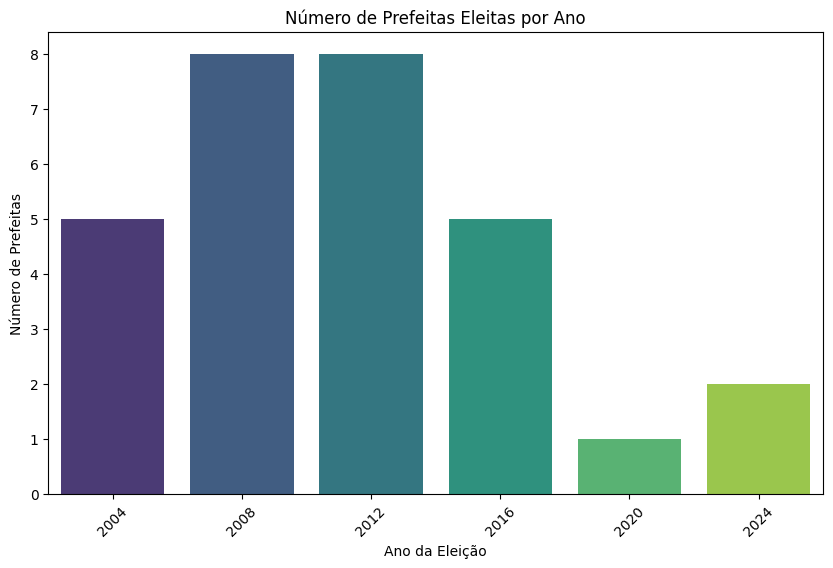

In [225]:
# Contando o número de prefeitas eleitas por ano
prefeitas_por_ano = prefeitas['ANO_ELEICAO'].value_counts().sort_index()

# Criando o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=prefeitas_por_ano.index, y=prefeitas_por_ano.values, palette='viridis')
plt.title('Número de Prefeitas Eleitas por Ano')
plt.xlabel('Ano da Eleição')
plt.ylabel('Número de Prefeitas')
plt.xticks(rotation=45)
plt.show()